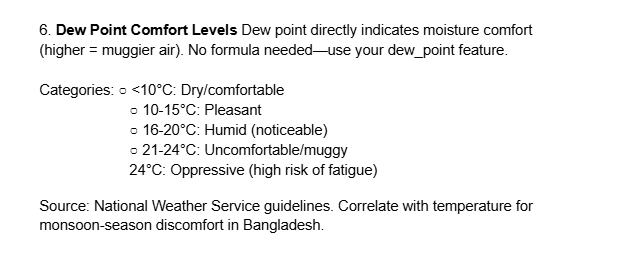

In [1]:
import pandas as pd

In [ ]:
df_bandarban = pd.read_csv('../1980-2024-dataset/Bagerhat_historical_weather_1980_2024.csv')

df_bandarban = df_bandarban.drop('district', axis =1 )

desired_colmn = ['day', 'month', 'year', 'dew_point']
df_bandarban = df_bandarban[desired_colmn]

df_bandarban = df_bandarban.dropna()

df_bandarban.head()

FileNotFoundError: [Errno 2] No such file or directory: '../../../1980-2024-dataset/Rangamati_historical_weather_1980_2024.csv'

Date range: 2014-01-01 to 2024-12-31


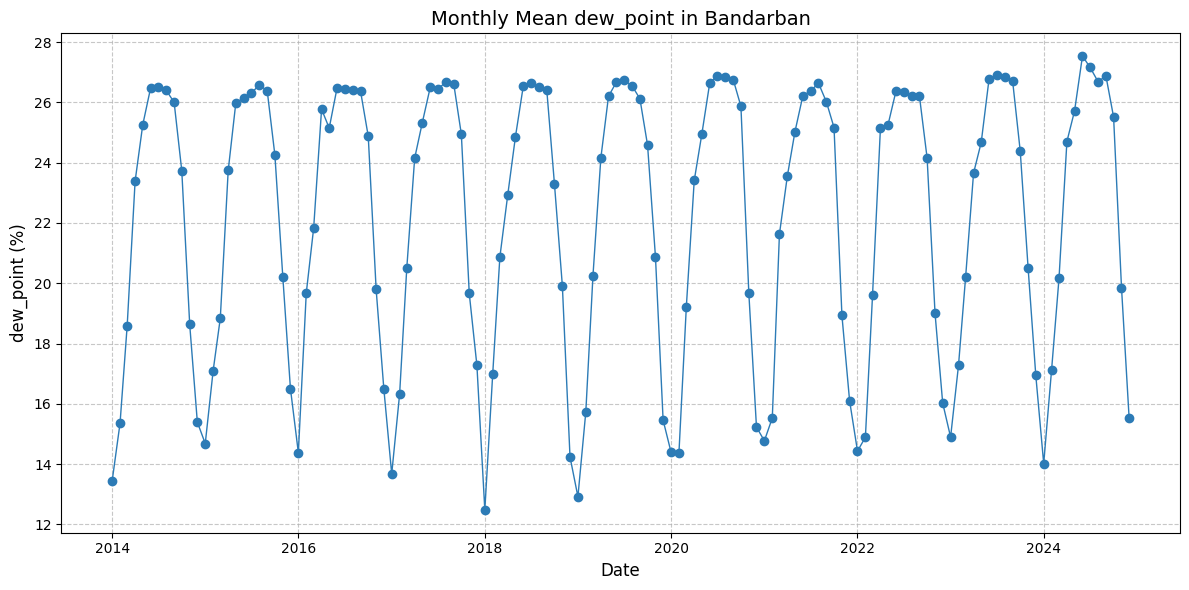

In [53]:
import matplotlib.pyplot as plt

if 'date' not in df_bandarban.columns:
    df_bandarban['date'] = pd.to_datetime(df_bandarban[['year', 'month', 'day']])

# # show date range
# min_date = df_bandarban['date'].min()
# max_date = df_bandarban['date'].max()
# print(f"Date range: {min_date.date()} to {max_date.date()}")

# 2010-2024 dile 83% r2 lightgbm
# 2014- 2024 dile 82% R2
# 2018-2024 dile 52% R2 xgboost

# filter data for custom date range: 2020 to 2024
df_bandarban = df_bandarban[
    (df_bandarban['date'] >= '2014-01-01') & (df_bandarban['date'] <= '2024-12-31')
]
custom_range_df = df_bandarban.copy()

# show date range
min_date = custom_range_df['date'].min()
max_date = custom_range_df['date'].max()

df_bandarban['date'] = pd.to_datetime(df_bandarban['date'])
df_bandarban.set_index('date', inplace=True)

df_monthly_hum = df_bandarban['dew_point'].resample('MS').mean()
# Fill missing gaps using linear interpolation (common for weather data)
df_monthly_hum = df_monthly_hum.interpolate(method='linear')

print(f"Date range: {min_date.date()} to {max_date.date()}")

# --- Plotting ---
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_hum, marker='o', linestyle='-', color='#2c7bb6', linewidth=1)
plt.title('Monthly Mean dew_point in Bandarban', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('dew_point (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# 1. Prepare Monthly Data
df = df_bandarban.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['dew_point'].resample('MS').mean().reset_index()
df_monthly = df_monthly.dropna()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]



In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score

FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['dew_point']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)


# RF

In [56]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_score,TimeSeriesSplit

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=6, 
    min_samples_split=2,
    min_samples_leaf=7,
    random_state=42,
    n_jobs=-1,
    max_features= 1.0
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rf_r2_f  = r2_score(y_test, y_pred)
rf_mse_f = mean_squared_error(y_test, y_pred)
rf_rmse_f = np.sqrt(rf_mse_f)

def tolerance_accuracy(y_true, y_hat, tol):
    """Return percentage of values within tolerance (works for multi-output)."""
    # y_true/y_hat shape: (n_samples, n_targets)
    return (np.abs(y_true - y_hat) <= tol).mean()

rf_acc_05 = tolerance_accuracy(y_test.values, y_pred, 0.5)
rf_acc_10 = tolerance_accuracy(y_test.values, y_pred, 1.0)
rf_acc_20 = tolerance_accuracy(y_test.values, y_pred, 2.0)
rf_acc_30 = tolerance_accuracy(y_test.values, y_pred, 3.0)

print("=== Random Forest + Fourier – Humidity Prediction (Test) ===")
print(f"R²          : {rf_r2_f:.4f}")
print(f"RMSE        : {rf_rmse_f:.3f} °C")
print(f"MSE         : {rf_mse_f:.4f}")
print("Accuracy (± tolerance):")
print(f"  ±0.5 °C : {rf_acc_05 * 100:5.2f}%")
print(f"  ±1.0 °C : {rf_acc_10 * 100:5.2f}%")
print(f"  ±2.0 °C : {rf_acc_20 * 100:5.2f}%")
print(f"  ±3.0 °C : {rf_acc_30 * 100:5.2f}%")

# ------------------------------------------------------------------
# 9. 5-fold CV (R²)
# ------------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

# 2. Run cross-validation using the tscv object
rf_cv_r2 = cross_val_score(rf, X, y, cv=tscv, scoring='r2', n_jobs=-1)

print("\n=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===")
print(f"Mean R² : {rf_cv_r2.mean():.4f}  (±{rf_cv_r2.std():.4f})")
print(f"Scores  : {np.round(rf_cv_r2, 4)}")

fi = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\n=== Feature Importances (Top 10) ===")
print(fi.head(10).to_string(index=False))


=== Random Forest + Fourier – Humidity Prediction (Test) ===
R²          : 0.9244
RMSE        : 1.210 °C
MSE         : 1.4640
Accuracy (± tolerance):
  ±0.5 °C : 48.15%
  ±1.0 °C : 66.67%
  ±2.0 °C : 88.89%
  ±3.0 °C : 96.30%



=== TimeSeriesSplit CV R² (Seasonal Trend Validation) ===
Mean R² : 0.8046  (±0.1549)
Scores  : [0.5408 0.7263 0.8598 0.9442 0.9519]

=== Feature Importances (Top 10) ===
 feature  importance
   cos_1    0.725518
   sin_1    0.137720
   sin_2    0.089355
   sin_3    0.028901
   cos_3    0.009296
   cos_2    0.008238
year_val    0.000971


# XGBoost 

In [57]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor

xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = xgb_model.predict(X_test)

xgboost_r2_f  = r2_score(y_test, y_pred)            # averaged R^2 for multioutput
xgboost_mse_f = mean_squared_error(y_test, y_pred)  # averaged MSE
xgboost_rmse_f = np.sqrt(xgboost_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    # returns fraction (0..1) of predictions within tol across all targets
    return ((np.abs(y_true - y_hat) <= tol).mean())

xgboost_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
xgboost_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
xgboost_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
xgboost_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== XGBoost Regression Metrics (Test) ====")
print(f"xgboost_R^2  : {xgboost_r2_f:.4f}")
print(f"xgboost_MSE  : {xgboost_mse_f:.4f}")
print(f"xgboost_RMSE : {xgboost_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {xgboost_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {xgboost_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {xgboost_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {xgboost_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)

xgb_cv_r2 = cross_val_score(xgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean xgboost_R^2 : {xgb_cv_r2.mean():.4f}  |  Std : {xgb_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---
# MultiOutputRegressor stores estimators_ after fit


fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.head(10).to_string(index=False))

==== XGBoost Regression Metrics (Test) ====
xgboost_R^2  : 0.9757
xgboost_MSE  : 0.4695
xgboost_RMSE : 0.6852
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 62.96%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean xgboost_R^2 : 0.9612  |  Std : 0.0153

==== Top Feature Importances ====
 feature  importance
   cos_1    0.478530
   sin_2    0.231154
   sin_1    0.126713
   sin_3    0.098123
   cos_3    0.039986
   cos_2    0.020061
year_val    0.005432


# light gbm

In [58]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor


# --- 4) Train MultiOutput LightGBM ---
import lightgbm as lgb

# Optimized for Seasonal Shape extraction on N=132
lgb_model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01,         # Slowed down for stable trend learning
    max_depth=4,                # Restricted depth to prevent memorizing noise
    num_leaves=10,              # Low number of leaves is critical for small data
    min_child_samples=5,        # Minimum data points in a leaf (prevents tiny, specific branches)
    
    subsample=0.7,              # Stochastic bagging for robustness
    subsample_freq=1,
    colsample_bytree=0.7,       # Feature bagging
    
    reg_alpha=0.2,              # L1 regularization
    reg_lambda=0.2,             # L2 regularization
    
    importance_type='gain',     # More useful for understanding "Shape" than 'split'
    random_state=42,
    n_jobs=-1,
    verbosity=-1                # Suppress warnings about small dataset
)

lgb_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = lgb_model.predict(X_test)

lgb_r2_f  = r2_score(y_test, y_pred)
lgb_mse_f = mean_squared_error(y_test, y_pred)
lgb_rmse_f = np.sqrt(lgb_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

lgb_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
lgb_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
lgb_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
lgb_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== LightGBM Regression Metrics (Test) ====")
print(f"LGB_R^2  : {lgb_r2_f:.4f}")
print(f"LGB_MSE  : {lgb_mse_f:.4f}")
print(f"LGB_RMSE : {lgb_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {lgb_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {lgb_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {lgb_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {lgb_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
lgb_cv_r2 = cross_val_score(lgb_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean LGB_R^2 : {lgb_cv_r2.mean():.4f}  |  Std : {lgb_cv_r2.std():.4f}")



fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== LightGBM Regression Metrics (Test) ====
LGB_R^2  : 0.9737
LGB_MSE  : 0.5086
LGB_RMSE : 0.7132
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 70.37%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean LGB_R^2 : 0.9581  |  Std : 0.0195

==== Top Feature Importances ====
 feature   importance
   cos_1 37994.883608
   sin_1 16391.006687
   sin_2 11784.956539
   sin_3  4345.155907
   cos_2  2724.512889
   cos_3  2654.451778
year_val  1230.124831


# cat boost

In [59]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.multioutput import MultiOutputRegressor
from catboost import CatBoostRegressor

# --- 4) Train MultiOutput LightGBM ---
cat_model = CatBoostRegressor(
    iterations=1500,           # Increased iterations with a lower learning rate
    learning_rate=0.01,        # "Crawl" toward the seasonal trend
    depth=4,                   # Shallower trees for better generalization on small N=132
    l2_leaf_reg=10,            # Higher L2 regularization to smooth the seasonal curve
    
    bootstrap_type='Bayesian',
    bagging_temperature=0.5,   # Reduced slightly for more stable bagging
    random_strength=2,         # Adds randomness to scoring splits, preventing overfitting
    
    loss_function='RMSE',      # Standard for regression; 'Huber' is also an option if data is noisy
    od_type='Iter',            # Overfitting detector
    od_wait=50,                # Stop early if the trend isn't improving
    
    random_seed=42,
    verbose=0
)


cat_model.fit(X_train, y_train)

# --- 5) Predictions & metrics ---
y_pred = cat_model.predict(X_test)

cat_r2_f  = r2_score(y_test, y_pred)
cat_mse_f = mean_squared_error(y_test, y_pred)
cat_rmse_f = np.sqrt(cat_mse_f)

def within_tolerance_acc(y_true, y_hat, tol):
    return ((np.abs(y_true - y_hat) <= tol).mean())

cat_acc_05 = within_tolerance_acc(y_test.values, y_pred, 0.5)
cat_acc_10 = within_tolerance_acc(y_test.values, y_pred, 1.0)
cat_acc_20 = within_tolerance_acc(y_test.values, y_pred, 2.0)
cat_acc_30 = within_tolerance_acc(y_test.values, y_pred, 3.0)

print("==== CatBoost Regression Metrics (Test) ====")
print(f"CatBoost_R^2  : {cat_r2_f:.4f}")
print(f"CatBoost_MSE  : {cat_mse_f:.4f}")
print(f"CatBoost_RMSE : {cat_rmse_f:.4f}")
print("Accuracy (|error| ≤ tolerance):")
print(f"  ±0.5°C : {cat_acc_05*100:5.2f}%")
print(f"  ±1.0°C : {cat_acc_10*100:5.2f}%")
print(f"  ±2.0°C : {cat_acc_20*100:5.2f}%")
print(f"  ±3.0°C : {cat_acc_30*100:5.2f}%")

# --- 6) 5-fold CV R^2 ---
tscv = TimeSeriesSplit(n_splits=5)
cat_cv_r2 = cross_val_score(cat_model, X, y, cv=tscv, scoring="r2", n_jobs=-1)

print("\n==== 5-Fold CV R^2 ====")
print(f"Mean CAT_R^2 : {cat_cv_r2.mean():.4f}  |  Std : {cat_cv_r2.std():.4f}")

# --- 7) Feature importances (average across outputs) ---

fi = pd.DataFrame({
    "feature": FEATURES, 
    "importance": cat_model.feature_importances_
}).sort_values("importance", ascending=False)

print("\n==== Top Feature Importances ====")
print(fi.to_string(index=False))


==== CatBoost Regression Metrics (Test) ====
CatBoost_R^2  : 0.9704
CatBoost_MSE  : 0.5722
CatBoost_RMSE : 0.7565
Accuracy (|error| ≤ tolerance):
  ±0.5°C : 66.67%
  ±1.0°C : 77.78%
  ±2.0°C : 100.00%
  ±3.0°C : 100.00%

==== 5-Fold CV R^2 ====
Mean CAT_R^2 : 0.9605  |  Std : 0.0156

==== Top Feature Importances ====
 feature  importance
   cos_1   51.162302
   sin_1   18.497602
   sin_2   14.277383
   sin_3    6.627915
   cos_3    4.172459
   cos_2    3.640308
year_val    1.622031


# comparision

In [60]:
# show the comparision of all the models in a table.based on R^2, MSE, RMSE, and accuracy within tolerances.
# Summary of model performance
model_performance = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LightGBM", "CatBoost"],
    "R^2": [rf_r2_f, xgboost_r2_f, lgb_r2_f, cat_r2_f],  # Replace with actual R^2 values from each model
    "CV R2": [rf_cv_r2.mean(), xgb_cv_r2.mean(), lgb_cv_r2.mean(), cat_cv_r2.mean()],
    "MSE": [rf_mse_f, xgboost_mse_f, lgb_mse_f, cat_mse_f],  # Replace with actual MSE values from each model
    "RMSE": [rf_rmse_f, xgboost_rmse_f, lgb_rmse_f, cat_rmse_f],  # Replace with actual RMSE values from each model
    "Acc ±0.5°C (%)": [rf_acc_05*100, xgboost_acc_05*100, lgb_acc_05*100, cat_acc_05*100],  # Replace with actual accuracy values
    "Acc ±1.0°C (%)": [rf_acc_10*100, xgboost_acc_10*100, lgb_acc_10*100, cat_acc_10*100],
    "Acc ±2.0°C (%)": [rf_acc_20*100, xgboost_acc_20*100, lgb_acc_20*100, cat_acc_20*100],
    "Acc ±3.0°C (%)": [rf_acc_30*100, xgboost_acc_30*100, lgb_acc_30*100, cat_acc_30*100],
})
print("\n==== Model Performance Comparison ====")
print(model_performance.to_string(index=False))



==== Model Performance Comparison ====
        Model      R^2    CV R2      MSE     RMSE  Acc ±0.5°C (%)  Acc ±1.0°C (%)  Acc ±2.0°C (%)  Acc ±3.0°C (%)
Random Forest 0.924367 0.804604 1.464032 1.209972       48.148148       66.666667       88.888889       96.296296
      XGBoost 0.975744 0.961244 0.469526 0.685220       62.962963       77.777778      100.000000      100.000000
     LightGBM 0.973724 0.958118 0.508626 0.713180       70.370370       77.777778      100.000000      100.000000
     CatBoost 0.970438 0.960485 0.572233 0.756461       66.666667       77.777778      100.000000      100.000000


In [61]:
# Simple Additive Weighting

def select_best_model_journal(df):
    """
    Journal-quality model selection using weighted scoring 
    and Overfitting Analysis.
    """
    # 1. Calculate Generalization Gap (Lower is better)
    # Measures the difference between training-like (CV) and testing performance
    df['Gen_Gap'] = abs(df['R^2'] - df['CV R2'])
    
    # 2. Define Metric Polarities (True = Maximize, False = Minimize)
    metrics = {
        'R^2': True, 
        'CV R2': True, 
        'RMSE': False, 
        'Gen_Gap': False, 
        'Acc ±1.0°C (%)': True
    }
    
    # 3. Min-Max Normalization to bring all metrics to 0-1 range
    # This ensures RMSE (2.5) doesn't outweigh R^2 (0.75) simply by scale
    df_norm = df.copy()
    for metric, maximize in metrics.items():
        min_val = df[metric].min()
        max_val = df[metric].max()
        if maximize:
            df_norm[metric] = (df[metric] - min_val) / (max_val - min_val)
        else:
            df_norm[metric] = (max_val - df[metric]) / (max_val - min_val)
            
    # 4. Compute Weighted Composite Score (WCS)
    # Weights can be adjusted based on the specific importance for the study
    weights = {'R^2': 0.25, 'CV R2': 0.25, 'RMSE': 0.20, 'Gen_Gap': 0.20, 'Acc ±1.0°C (%)': 0.10}
    df['Composite_Score'] = sum(df_norm[m] * weights[m] for m in weights)
    
    # 5. Rank and Flag Overfitting
    df['Status'] = np.where(df['Gen_Gap'] > 0.1, 'Overfit Risk', 'Robust')
    
    return df.sort_values('Composite_Score', ascending=False)

# Execute
journal_results = select_best_model_journal(model_performance)
print(journal_results[['Model', 'R^2', 'CV R2', 'Gen_Gap', 'Composite_Score', 'Status']])

           Model       R^2     CV R2   Gen_Gap  Composite_Score        Status
1        XGBoost  0.975744  0.961244  0.014500         0.991718        Robust
2       LightGBM  0.973724  0.958118  0.015606         0.964231        Robust
3       CatBoost  0.970438  0.960485  0.009953         0.945818        Robust
0  Random Forest  0.924367  0.804604  0.119763         0.000000  Overfit Risk


# predicting with best model for two years

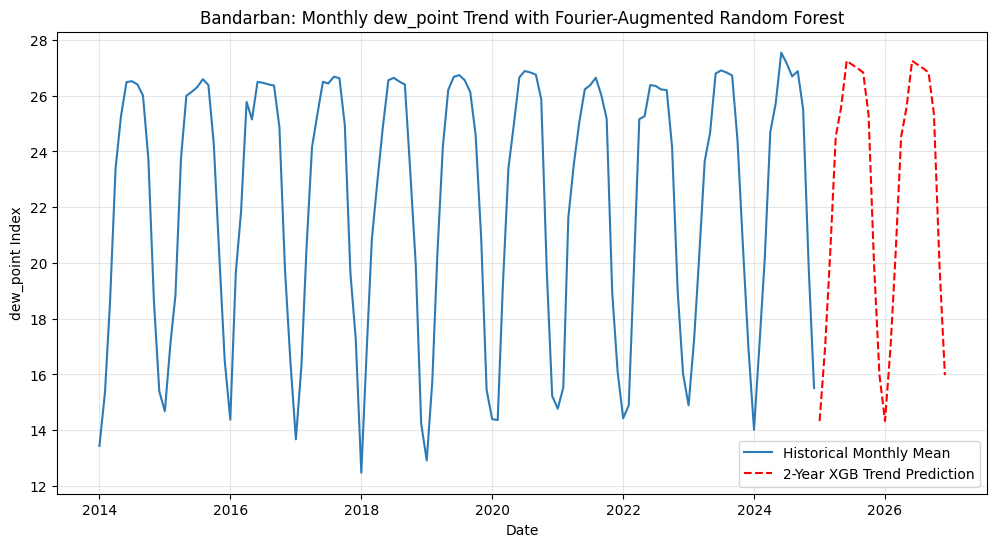

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

# 1. Prepare Monthly Data
df = df_bandarban.copy() # [cite: 101]
df['date'] = pd.to_datetime(df[['year', 'month', 'day']]) # [cite: 116]
df_monthly = df.set_index('date')['dew_point'].resample('MS').mean().reset_index()

# 2. Engineering Fourier Features for Seasonality
# This replaces the need for interpolation/splines
def add_fourier_features(df, period=12, n_terms=3): # Monthly period is 12
    for n in range(1, n_terms + 1):
        # Using month index (1-12) as the base for the cycle
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly.copy())
df_features['year_val'] = df_features['date'].dt.year

# 3. Define Features and Target
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['dew_point']

# 4. Train Random Forest [cite: 145, 146]
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# 5. Predict 2 Years Future (24 months)
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)

predictions_temp = xgb_model.predict(future_df[FEATURES])

# 6. Visualization
plt.figure(figsize=(12, 6))
plt.plot(df_features['date'], y, label='Historical Monthly Mean', color='#2c7bb6') # [cite: 80]
plt.plot(future_dates, predictions_temp, label='2-Year XGB Trend Prediction', linestyle='--', color='red')
plt.title('Bandarban: Monthly dew_point Trend with Fourier-Augmented Random Forest')
plt.xlabel('Date')
plt.ylabel('dew_point Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

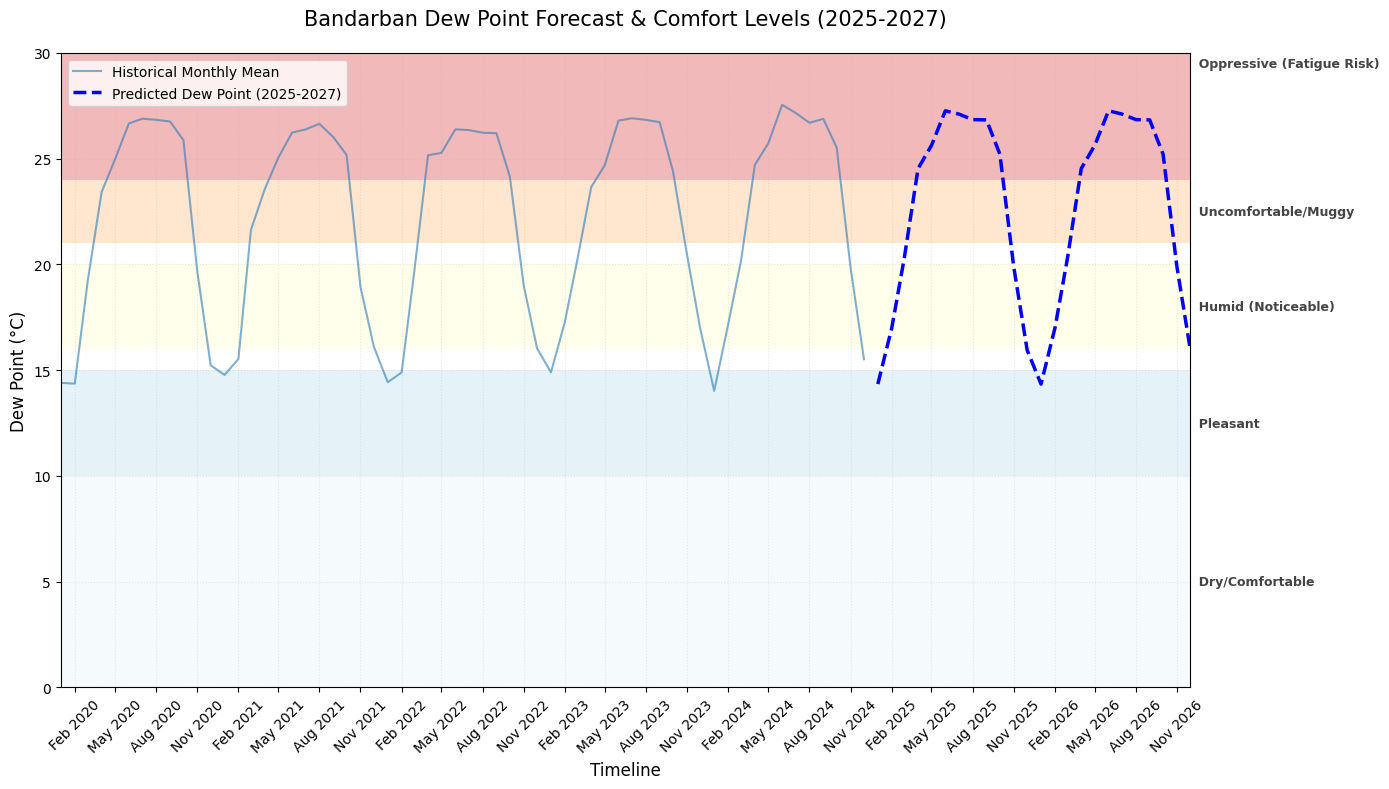

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb

# --- 1. Data Preparation & Feature Engineering ---
# Assuming df_bandarban exists in your environment
df_historical = df_bandarban.copy() 
df_historical['date'] = pd.to_datetime(df_historical[['year', 'month', 'day']]) 

# Resample to Monthly Mean
df_monthly = df_historical.set_index('date')['dew_point'].resample('MS').mean().reset_index()

def add_fourier_features(df, period=12, n_terms=3):
    df = df.copy()
    for n in range(1, n_terms + 1):
        # Ensure we use the month from the date column
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period) 
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period) 
    return df

df_train = add_fourier_features(df_monthly)
df_train['year_val'] = df_train['date'].dt.year

fourier_cols = [c for c in df_train.columns if 'sin' in c or 'cos' in c] 
FEATURES = ['year_val'] + fourier_cols
X = df_train[FEATURES]
y = df_train['dew_point']

# --- 2. Model Training (XGBoost) ---
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)
xgb_model.fit(X, y)

# Generate 24-month forecast (2025-2027)
last_date = df_train['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
df_forecast = pd.DataFrame({'date': future_dates})
df_forecast['year_val'] = df_forecast['date'].dt.year
df_forecast = add_fourier_features(df_forecast)

# Predict using the trained XGBoost model
df_forecast['Predicted_dew_point'] = xgb_model.predict(df_forecast[FEATURES])

# --- 3. Enhanced Visualization (Based on Provided Comfort Levels) ---
plt.figure(figsize=(14, 8))
ax = plt.gca()

# Plotting lines
plt.plot(df_train['date'], y, label='Historical Monthly Mean', color='#2c7bb6', alpha=0.6)
plt.plot(df_forecast['date'], df_forecast['Predicted_dew_point'], 
         label='Predicted Dew Point (2025-2027)', color='blue', linewidth=2.5, linestyle='--')

# Dew Point Comfort Bands (Updated per your image)
# Format: (Low_Val, High_Val, Label, Color)
comfort_bands = [
    (0, 10, "Dry/Comfortable", "#e0f3f8"),
    (10, 15, "Pleasant", "#abd9e9"),
    (16, 20, "Humid (Noticeable)", "#ffffbf"),
    (21, 24, "Uncomfortable/Muggy", "#fdae61"),
    (24, 35, "Oppressive (Fatigue Risk)", "#d7191c") # Upper bound set to 35 for padding
]

for low, high, label, color in comfort_bands:
    ax.axhspan(low, high, facecolor=color, alpha=0.3, edgecolor=None)
    # Positioning the text label on the right side of the plot
    plt.text(df_forecast['date'].iloc[-1], (low + high) / 2, f'  {label}', 
             fontsize=9, fontweight='bold', color="#444444", va="center")

# Formatting
plt.title('Bandarban Dew Point Forecast & Comfort Levels (2025-2027)', fontsize=15, pad=20)
plt.xlabel("Timeline", fontsize=12)
plt.ylabel('Dew Point (°C)', fontsize=12)
plt.ylim(0, 30) 

# Date Formatting
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.grid(True, which='both', linestyle=':', alpha=0.3)
plt.legend(loc='upper left', frameon=True, facecolor='white')
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.tight_layout()
plt.show()

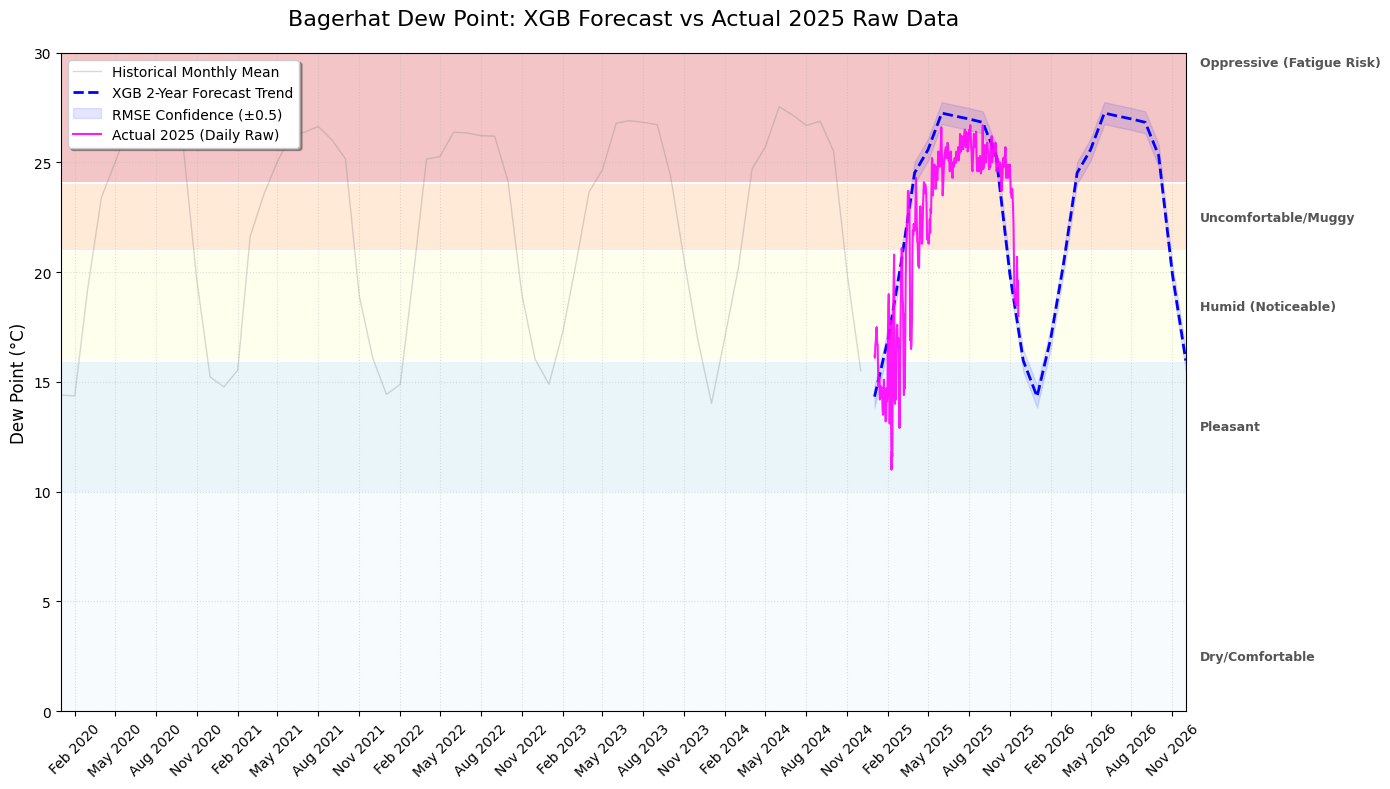

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

# --- 1. Load and Prepare Historical Data ---
df_bandarban = pd.read_csv('../1980-2024-dataset/Bagerhat_historical_weather_1980_2024.csv')
df = df_bandarban.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Resample to Monthly Mean
df_monthly = df.set_index('date')['dew_point'].resample('MS').mean().reset_index()

# --- 2. Engineering Fourier Features for Seasonality ---
def add_fourier_features(df, period=12, n_terms=3):
    df = df.copy()
    for n in range(1, n_terms + 1):
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_monthly)
df_features['year_val'] = df_features['date'].dt.year

# --- 3. Define Features and Target ---
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['dew_point']

# --- 4. Train Random Forest ---
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,          # Increased, but we will rely on a low learning rate
    learning_rate=0.01,         # Much lower to "crawl" toward the seasonal shape
    max_depth=4,                # Shallower trees prevent the model from memorizing specific years
    
    # --- Regularization to handle small N=132 ---
    reg_alpha=0.1,              # L1 regularization to keep feature weights stable
    reg_lambda=1.0,             # L2 regularization to prevent extreme predictions
    subsample=0.8,              # Use 80% of data per tree to add robustness
    colsample_bytree=0.8,       # Randomly select features to reduce dominance of sin_1
    
    # --- Optimization ---
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)


# --- 5. Predict 2 Years Future ---
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)
predictions_dew_point = xgb_model.predict(future_df[FEATURES])

# --- 6. Load 2025 Validation Data ---
df_2025 = pd.read_csv('../2025-dataset/bandarban_historical_weather_2025.csv')
df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])
# Keep RAW daily data for the "raw curve" over the prediction
df_2025_raw = df_2025.set_index('date')['dew_point']

# --- 7. Integrated Visualization ---
fig, ax = plt.subplots(figsize=(14, 8))

# A. Historical Data (Faded background)
ax.plot(df_features['date'], y, label='Historical Monthly Mean', color='gray', linewidth=1, alpha=0.3)

# B. Prediction Trend & Confidence Cloud
error_margin = 0.50 
ax.plot(future_dates, predictions_dew_point, label='XGB 2-Year Forecast Trend', 
        linestyle='--', color='blue', linewidth=2, zorder=4)
ax.fill_between(future_dates, predictions_dew_point - error_margin, predictions_dew_point + error_margin, 
                color='blue', alpha=0.1, label=f'RMSE Confidence (±{error_margin})', zorder=3)

# C. Actual 2025 RAW Data (Plotted OVER the predicted line)
ax.plot(df_2025_raw.index, df_2025_raw.values, label='Actual 2025 (Daily Raw)', 
        color='magenta', linewidth=1.5, zorder=10, alpha=0.9)

# D. Updated Comfort Level Bands (Per Image Guidelines)
comfort_bands = [
    (-5, 10, "Dry/Comfortable", "#e0f3f8"),
    (10, 15.9, "Pleasant", "#abd9e9"),
    (16, 20.9, "Humid (Noticeable)", "#ffffbf"),
    (21, 24, "Uncomfortable/Muggy", "#fdae61"),
    (24.1, 35, "Oppressive (Fatigue Risk)", "#d7191c")
]

for low, high, label, color in comfort_bands:
    ax.axhspan(low, high, facecolor=color, alpha=0.25, edgecolor=None)
    # Label placement on the right margin
    plt.text(future_dates[-1] + pd.DateOffset(months=1), (low + high) / 2, label, 
             fontsize=9, fontweight='bold', color="#555555", va="center")

# Formatting
ax.set_title('Bagerhat Dew Point: XGB Forecast vs Actual 2025 Raw Data', fontsize=16, pad=20)
ax.set_ylabel('Dew Point (°C)', fontsize=12)
ax.set_ylim(0, 30) # Adjusted for dew point range
ax.set_xlim(pd.Timestamp('2023-01-01'), future_dates.max()) # Zoomed for better visibility

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend(loc='upper left', frameon=True, facecolor='white', shadow=True)
ax.grid(True, linestyle=':', alpha=0.4)
plt.xlim(pd.Timestamp('2020-01-01'), future_dates.max())
plt.tight_layout()
plt.show()

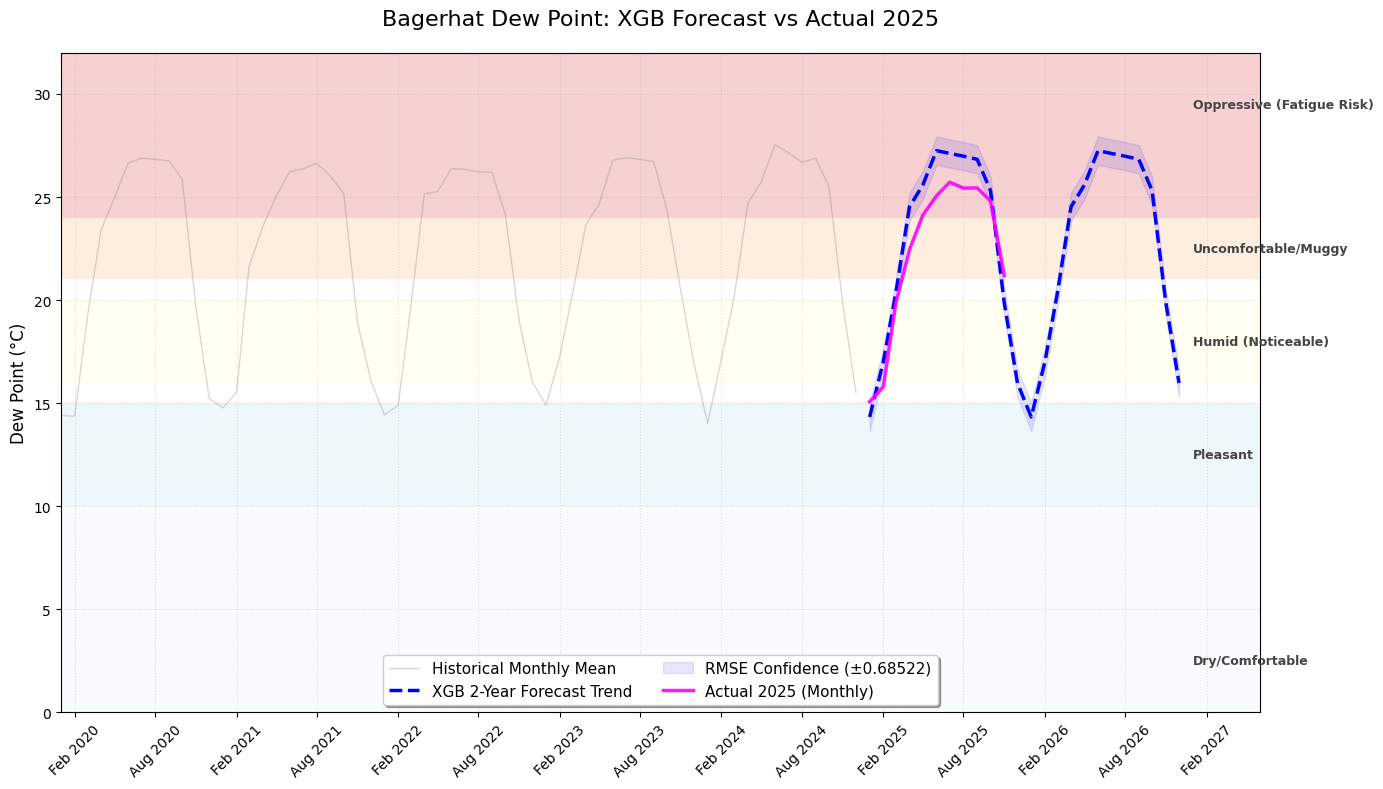

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb

# --- 1. Load and Prepare Historical Data ---
df_bandarban = pd.read_csv('../1980-2024-dataset/Bagerhat_historical_weather_1980_2024.csv')
df = df_bandarban.copy()
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

# Resample to Monthly Mean and Reset Index to create a proper DataFrame
df_features = df.set_index('date')['dew_point'].resample('MS').mean().reset_index()

# --- 2. Engineering Fourier Features for Seasonality ---
def add_fourier_features(df, period=12, n_terms=3):
    df = df.copy()
    for n in range(1, n_terms + 1):
        months = df['date'].dt.month
        df[f'sin_{n}'] = np.sin(2 * np.pi * n * months / period)
        df[f'cos_{n}'] = np.cos(2 * np.pi * n * months / period)
    return df

df_features = add_fourier_features(df_features)
df_features['year_val'] = df_features['date'].dt.year

# --- 3. Define Features and Target ---
fourier_cols = [c for c in df_features.columns if 'sin' in c or 'cos' in c]
FEATURES = ['year_val'] + fourier_cols
X = df_features[FEATURES]
y = df_features['dew_point']

# --- 4. Train XGBoost (Updated to use consistent variable names) ---
xgb_model = xgb.XGBRegressor( 
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=4,
    reg_alpha=0.1,
    reg_lambda=1.0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)

# --- 5. Predict 2 Years Future ---
last_date = df_features['date'].max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=24, freq='MS')
future_df = pd.DataFrame({'date': future_dates})
future_df['year_val'] = future_df['date'].dt.year
future_df = add_fourier_features(future_df)
predictions_dew_point = xgb_model.predict(future_df[FEATURES])

# --- 6. Load 2025 Validation Data ---
df_2025 = pd.read_csv('../2025-dataset/bandarban_historical_weather_2025.csv')
df_2025['date'] = pd.to_datetime(df_2025[['year', 'month', 'day']])

# Turn 2025 data into the EXACT same dataframe structure as df_features
df_2025_monthly = df_2025.set_index('date')['dew_point'].resample('MS').mean().reset_index()

# --- 7. Integrated Visualization ---
fig, ax = plt.subplots(figsize=(14, 8))

# A. Historical Data (Faded background)
ax.plot(df_features['date'], df_features['dew_point'], label='Historical Monthly Mean', color='gray', linewidth=1, alpha=0.3)

# B. Prediction Trend & Confidence Cloud
error_margin = 0.685220      
ax.plot(future_df['date'], predictions_dew_point, label='XGB 2-Year Forecast Trend', 
        linestyle='--', color='blue', linewidth=2.5, zorder=4)
ax.fill_between(future_df['date'], predictions_dew_point - error_margin, predictions_dew_point + error_margin, 
                color='blue', alpha=0.1, label=f'RMSE Confidence (±{error_margin})', zorder=3)

# C. Actual 2025 Monthly Data (Plotted OVER the predicted line)
# Accessing via column names ['date'] and ['dew_point'] just like df_features
ax.plot(df_2025_monthly['date'], df_2025_monthly['dew_point'], label='Actual 2025 (Monthly)', 
        color='magenta', linewidth=2.5, zorder=10, alpha=0.9)

# D. Comfort Level Bands (Per Image Guidelines)
comfort_bands = [
    (-5, 10, "Dry/Comfortable", "#e0f3f8"),
    (10, 15, "Pleasant", "#abd9e9"),
    (16, 20, "Humid (Noticeable)", "#ffffbf"),
    (21, 24, "Uncomfortable/Muggy", "#fdae61"),
    (24, 35, "Oppressive (Fatigue Risk)", "#d7191c")
]

for low, high, label, color in comfort_bands:
    ax.axhspan(low, high, facecolor=color, alpha=0.2, edgecolor=None)
    # Positioning text on the far right
    plt.text(future_df['date'].max() + pd.DateOffset(months=1), (low + high) / 2, label, 
             fontsize=9, fontweight='bold', color="#444444", va="center")

# Formatting
ax.set_title('Bagerhat Dew Point: XGB Forecast vs Actual 2025', fontsize=16, pad=20)
ax.set_ylabel('Dew Point (°C)', fontsize=12)
ax.set_ylim(0, 32)
ax.set_xlim(pd.Timestamp('2020-01-01'), future_df['date'].max() + pd.DateOffset(months=6))

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

ax.legend(loc='lower center', fontsize=11, frameon=True, facecolor='white', shadow=True, ncol=2)
ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [65]:
# create the dataframe of the predicted values of 2025 and 2026
df_predictions_dew_point = pd.DataFrame({
    'date': future_dates,
    'predicted_dew_point': predictions_dew_point
})



In [66]:
df_predictions_dew_point.head(10)

,date,predicted_dew_point
0,2025-01-01,14.327452
1,2025-02-01,17.007942
2,2025-03-01,20.326235
3,2025-04-01,24.525597
4,2025-05-01,25.577915
5,2025-06-01,27.252743
6,2025-07-01,27.114216
7,2025-08-01,26.983318
8,2025-09-01,26.829704
9,2025-10-01,25.318394
